In [14]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy import stats

### Ejercicio 1 

In [2]:
## Ejercicio 1
'''
Sea Z ~ N(0,1), con densidad phi(z).

a. E(Z)=0 porque z*phi(z) es una función impar: z cambia de signo y phi(z) es simétrica.
   Por lo tanto, el área negativa cancela exactamente el área positiva.

b. Var(Z)=E(Z^2)-[E(Z)]^2. Como E(Z)=0, Var(Z)=E(Z^2). Para la normal estándar, E(Z^2)=1. 
    Intuitivamente, al ser estándar, su desvío es 1 y su varianza también es 1.

c. E(Z^3)=0 porque z^3*phi(z) también es impar.
    La parte negativa y la positiva se cancelan por simetría.

d. E(Z^4)=3. Este resultado sale por integración por partes y es el cuarto momento central de la normal estándar.
    Como Var(Z)=1, la curtosis total es E(Z^4)/Var(Z)^2 = 3.

'''

'\nSea Z ~ N(0,1), con densidad phi(z).\n\na. E(Z)=0 porque z*phi(z) es una función impar: z cambia de signo y phi(z) es simétrica.\n   Por lo tanto, el área negativa cancela exactamente el área positiva.\n\nb. Var(Z)=E(Z^2)-[E(Z)]^2. Como E(Z)=0, Var(Z)=E(Z^2). Para la normal estándar, E(Z^2)=1. \n    Intuitivamente, al ser estándar, su desvío es 1 y su varianza también es 1.\n\nc. E(Z^3)=0 porque z^3*phi(z) también es impar.\n    La parte negativa y la positiva se cancelan por simetría.\n\nd. E(Z^4)=3. Este resultado sale por integración por partes y es el cuarto momento central de la normal estándar.\n    Como Var(Z)=1, la curtosis total es E(Z^4)/Var(Z)^2 = 3.\n\n'

### Ejercicio 2

In [ ]:
z = np.arange(-8,8,0.1) # Me armo la columna desde -8 a 8

normal_0_1 = norm.pdf(z, loc=0, scale=1)

normal_m15_4 = norm.pdf(z, loc=-1.5, scale=2) # Ojo: scale = desvio estandar = sqrt(4) = 2

mixtura = 0.75*normal_0_1+0.25*normal_m15_4

mix_df = pd.DataFrame({
"z": z ,
"pdf_0_1": normal_0_1,
"pdf_m15_4": normal_m15_4,
"pdf_mixtura": mixtura
})

mix_df.head()

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(mix_df['z'], mix_df['pdf_0_1'],label='N(0,1)')
plt.plot(mix_df['z'], mix_df['pdf_m15_4'],label='N(-1.5,4)')
plt.plot(mix_df['z'], mix_df['pdf_mixtura'],label='mixtura')

plt.title('Normales')
plt.xlabel('z')
plt.ylabel('density')
plt.legend()
plt.show()

Desde aca se ve claramente la asimetria... tiene asimetria negativa, de cualquier manera lo sabemos pq es una mixtura de 0.75*0-1.5*0.25 de media. es asimetrica negativa. 

In [13]:
w1 = 0.75
w2 = 0.25

mu1 = 0
var1 = 1
sigma1 = np.sqrt(var1)

mu2 = -1.5
var2 = 4
sigma2 = np.sqrt(var2)

# Media de la mixtura
media_mix = w1 * mu1 + w2 * mu2

# Varianza de la mixtura
var_mix = (
    w1 * (var1 + (mu1 - media_mix)**2)
    + w2 * (var2 + (mu2 - media_mix)**2)
)

# Momentos centrales 3 y 4 de la mixtura
mu3_mix = (
    w1 * ((mu1 - media_mix)**3 + 3 * (mu1 - media_mix) * var1)
    + w2 * ((mu2 - media_mix)**3 + 3 * (mu2 - media_mix) * var2)
)

mu4_mix = (
    w1 * ((mu1 - media_mix)**4 + 6 * (mu1 - media_mix)**2 * var1 + 3 * var1**2)
    + w2 * ((mu2 - media_mix)**4 + 6 * (mu2 - media_mix)**2 * var2 + 3 * var2**2)
)

asimetria = mu3_mix / (var_mix ** 1.5)
curtosis = mu4_mix / (var_mix ** 2)

print(f' Para la mixtura, la media es {media_mix} y su varianza es {var_mix} \n por otro lado, la asimetria es {asimetria}, y su {curtosis}')

 Para la mixtura, la media es -0.375 y su varianza es 2.171875 
 por otro lado, la asimetria es -0.8896830643693507, y su 4.853009678588065


In [16]:
ticker = "MELI"

df_meli = yf.download(
    ticker,
    period="5y",
    interval="1d",
    auto_adjust=True
)

df_meli.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,MELI,MELI,MELI,MELI,MELI
Date,,,,,
2021-08-25,1871.939941,1872.300049,1844.449951,1860.869995,260300
2021-08-26,1835.680054,1864.489990,1827.510010,1864.489990,262000
2021-08-27,1865.000000,1874.560059,1830.920044,1835.000000,253400
2021-08-30,1878.900024,1910.000000,1853.550049,1853.550049,285400
2021-08-31,1867.449951,1891.069946,1848.219971,1890.000000,278400


In [24]:
meli = pd.DataFrame()

meli["Close"] = df_meli["Close"]["MELI"]
meli["ret"] = meli["Close"].pct_change()

meli.head(10)

,Close,ret
Date,,
2021-08-25,1871.939941,NaN
2021-08-26,1835.680054,-0.019370
2021-08-27,1865.000000,0.015972
2021-08-30,1878.900024,0.007453
2021-08-31,1867.449951,-0.006094
2021-09-01,1896.510010,0.015561
2021-09-02,1931.329956,0.018360
2021-09-03,1946.010010,0.007601
2021-09-07,1953.829956,0.004018


In [26]:
ret = meli['ret'].dropna()
ret

,ret
Date,
2021-08-26,-0.019370
2021-08-27,0.015972
2021-08-30,0.007453
2021-08-31,-0.006094
2021-09-01,0.015561
...,...
2026-08-18,-0.004716
2026-08-19,0.072794
2026-08-20,0.006973


In [ ]:
media_meli = ret.mean()
volat_meli = ret.std()
asimetria = stats.skew(ret)
curtosis = stats.kurtosis(ret,fisher=False)

print(f'media --> {media_meli}\nstd --> {volat_meli}\nasimetria --> {asimetria}\ncurtosis --> {curtosis}')

media --> 0.0005198221692600082
std -->0.031187829034736086
asimetria --> -0.09185347281141681
curtosis --> 6.52905490094566


<function matplotlib.pyplot.show(close=None, block=None)>

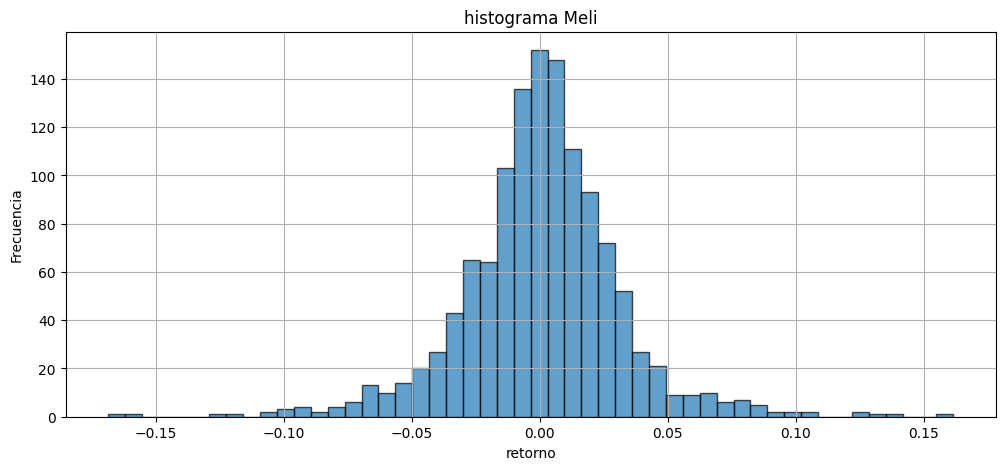

In [31]:
plt.figure(figsize=(12,5))
plt.hist(ret, bins=50 , edgecolor='black', alpha=0.7)

plt.title("histograma Meli")
plt.xlabel("retorno")
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show

In [32]:
jb_stat, jb_pvalue = stats.jarque_bera(ret)


print("Jarque-Bera:", jb_stat)
print("p-value:", jb_pvalue)

if jb_pvalue < 0.05:
    print("Rechazamos normalidad al 5%")
else:
    print("No rechazamos normalidad al 5%")

Jarque-Bera: 651.9764520793996
p-value: 2.6614129486133326e-142
Rechazamos normalidad al 5%


In [34]:
meli['ret_log'] = np.log(meli['Close']/meli['Close'].shift(1))
ret_log = meli['ret_log'].dropna()

ret_log.head()

,ret_log
Date,
2021-08-26,-0.019560
2021-08-27,0.015846
2021-08-30,0.007425
2021-08-31,-0.006113
2021-09-01,0.015442


In [37]:
mes = "2025-06"

ret_log_mes = meli.loc[mes, "ret_log"].sum()

precio_fin = meli.loc[mes, "Close"].iloc[-1]

primer_dia_mes = meli.loc[mes].index[0]
pos_primer_dia = meli.index.get_loc(primer_dia_mes)

precio_anterior = meli["Close"].iloc[pos_primer_dia - 1]

ret_log_total = np.log(precio_fin / precio_anterior)

print("Suma retornos log diarios:", ret_log_mes)
print("Retorno log mensual directo:", ret_log_total)

Suma retornos log diarios: 0.019448409948115964
Retorno log mensual directo: 0.01944840994811621
